In [2]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB
from gurobipy import quicksum
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import datetime
import os

from functions import (plot_DA_week,
                    load_da_market_data,
                    load_fcr_prices,
                    plot_fcr_prices,
                    load_afrr_capacity_prices,
                    generate_fcr_price_forecasts,
                    build_acceptance_rate,)

## Parameters


In [3]:
#Saturation Parameters
saturation_start_year = 2028
generate_fcr_price_forecasts(saturation_start_year)
activation_counter = 0

ACCEPTANCE_START_YEAR = 2024
ACCEPTANCE_END_YEAR = 2044

acceptance_rate = build_acceptance_rate(ACCEPTANCE_START_YEAR, ACCEPTANCE_END_YEAR, saturation_start_year)

print("Acceptance rates:")
for year in range(ACCEPTANCE_START_YEAR, ACCEPTANCE_END_YEAR + 1):
    print(f"Year {year}: {acceptance_rate[year]:.2%}")

#Battery Parameters
battery_capacity = 40 #[MWh]
initial_capacity = battery_capacity  # MWh
degradation_per_year = 0.5  # MWh/year
SOC_min = 1 #[Mwh]
charge_rate_min = 0 #[MW]
discharge_rate_min = 0 #[MW]
charge_rate_max = 10 #[MW]
discharge_rate_max = 10 #[MW]
efficiency = 0.99
self_discharge_rate = 3e-5 #per hour, corresponding to approx. 2% per month, we could just leave it to 0.
initial_SOC = 20 #[MWh]

#Market Parameters:
    #DA:
minimum_bid_DA = 0.1 #[MW]
granularity_DA = 1 #hours

    #FCR:
minimum_bid_FCR = 1 #[MW]
granularity_FCR = 4 #hours
wcs_factor_FCR = [0.36, 0.27, 0.18, 0.09] #[MWh/MW] #worst case scenario energy content reserve factors for each hour in the 4-hour FCR bid period

    #AFRR:
minimum_bid_AFRR = 5 #[MW]
granularity_AFRR = 24 #in reality the auction is weekly, not daily
wcs_factor_AFRR = 1.8 #MWh/MW how much we virtually reduce our remaining battery capacity to allow low risk participation in other markets
utilization_factor_AFRR = 0.05 #defined as the emperical ratio of activated energy bid volume vs available balancing energy bid volume: https://www.swissgrid.ch/content/dam/swissgrid/customers/topics/energy-data-ch/Swissgrid-TSO-report-on-balancing-V2020.pdf

AFRR_Pos_Act_price = 53 #[CHF/MWh] #average activation price for aFRR up regulation, considered constant
AFRR_Neg_Act_price = 32.19 #[CHF/MWh] #average activation price for aFRR down regulation

Loading base year profile from data\Swissgrid_PRL_SRL_TRL\PRL_filled_2024.csv
Base year 2024 mean price: 16.05
Linear decline 15.26 → 9.00 by 2028 (-2.0867 per year)
2025: target avg=15.26, scale=0.9505, rows=2190
2026: target avg=13.17, scale=0.8206, rows=2190
2027: target avg=11.09, scale=0.6906, rows=2190
2028: target avg=9.00, scale=0.5606, rows=2196
2029: target avg=9.00, scale=0.5606, rows=2190
2030: target avg=9.00, scale=0.5606, rows=2190
2031: target avg=9.00, scale=0.5606, rows=2190
2032: target avg=9.00, scale=0.5606, rows=2196
2033: target avg=9.00, scale=0.5606, rows=2190
2034: target avg=9.00, scale=0.5606, rows=2190
2035: target avg=9.00, scale=0.5606, rows=2190
2036: target avg=9.00, scale=0.5606, rows=2196
2037: target avg=9.00, scale=0.5606, rows=2190
2038: target avg=9.00, scale=0.5606, rows=2190
2039: target avg=9.00, scale=0.5606, rows=2190
2040: target avg=9.00, scale=0.5606, rows=2196
2041: target avg=9.00, scale=0.5606, rows=2190
2042: target avg=9.00, scale=0.5

## Data Loading


In [4]:
# Load Day-Ahead Market Prices
da_folder = "data/energy-charts_day_ahead"
years_to_load = [2024]  # available years span 2015-2024

# Load Day-Ahead Market Prices
DA_prices_merged = load_da_market_data(da_folder, years_to_load)
DA_prices_merged["timestamp"] = pd.to_datetime(DA_prices_merged["timestamp"])
DA_prices_merged["timestamp"] = DA_prices_merged["timestamp"] + pd.Timedelta(hours=1) # shift by one hour to fit local time
# Remove timezone information to match FCR timestamps
DA_prices_merged["timestamp"] = DA_prices_merged["timestamp"].dt.tz_localize(None)
DA_prices_merged = DA_prices_merged.sort_values("timestamp").reset_index(drop=True)
#DA_prices_merged["delivery_day"] = DA_prices_merged["timestamp"].dt.floor("D") # create delivery day column

print(f"Loaded {len(DA_prices_merged)} hourly day-ahead price points.")
DA_prices_merged.head()

# print(DA_prices_merged["timestamp"].min())
# print(DA_prices_merged["timestamp"].max())
# print(DA_prices_merged["timestamp"].dt.year.value_counts().sort_index())

Loaded 8784 hourly day-ahead price points.


,timestamp,price_eur_mwh
0,2024-01-01 00:00:00,25.97
1,2024-01-01 01:00:00,21.99
2,2024-01-01 02:00:00,14.32
3,2024-01-01 03:00:00,11.37
4,2024-01-01 04:00:00,11.35


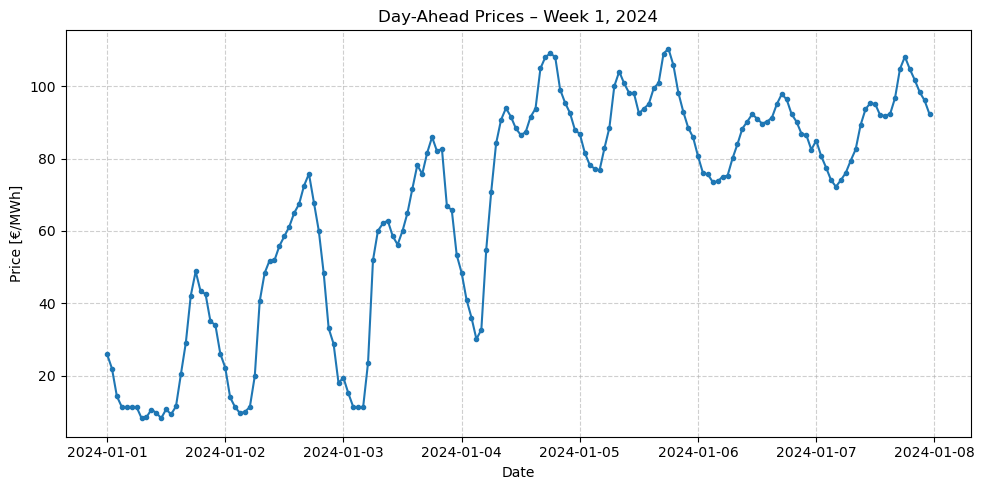

In [5]:
plot_DA_week(DA_prices_merged, year=2024, week=1) #Plot the DA prices for a given week

In [6]:
# =========================
# Load FCR (PRL) prices
# =========================
fcr_folder = "data/Swissgrid_PRL_SRL_TRL"
years_to_load_FCR = [2024]

merged_FCR = load_fcr_prices(fcr_folder, years_to_load_FCR).copy()
# Timestamps in that CSV indicate the hour at which the 4h block starts.
merged_FCR["timestamp"] = pd.to_datetime(merged_FCR["timestamp"])

merged_FCR = merged_FCR.sort_values("timestamp").reset_index(drop=True)
merged_FCR.head()

print(f"Loaded {len(merged_FCR)} FCR blocks.")
merged_FCR.head()

Loaded and merged 1 FCR files (2196 total rows).
Loaded 2196 FCR blocks.


,timestamp,Preis
0,2024-01-01 00:00:00,28.7
1,2024-01-01 04:00:00,26.1
2,2024-01-01 08:00:00,17.2
3,2024-01-01 12:00:00,19.4
4,2024-01-01 16:00:00,18.1


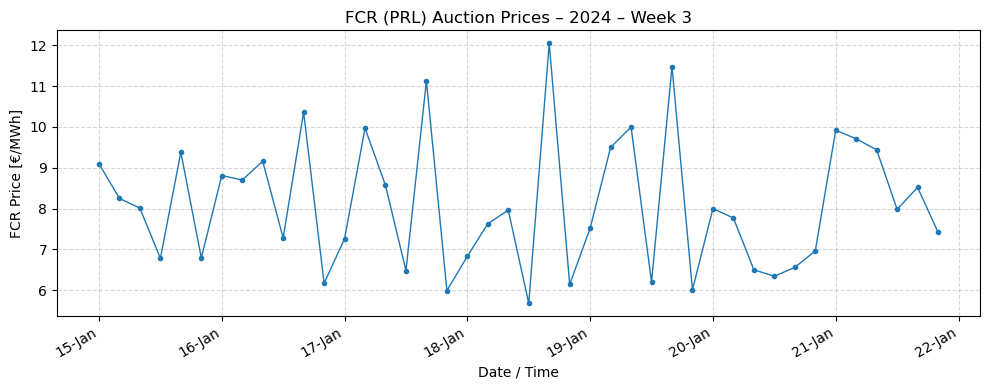

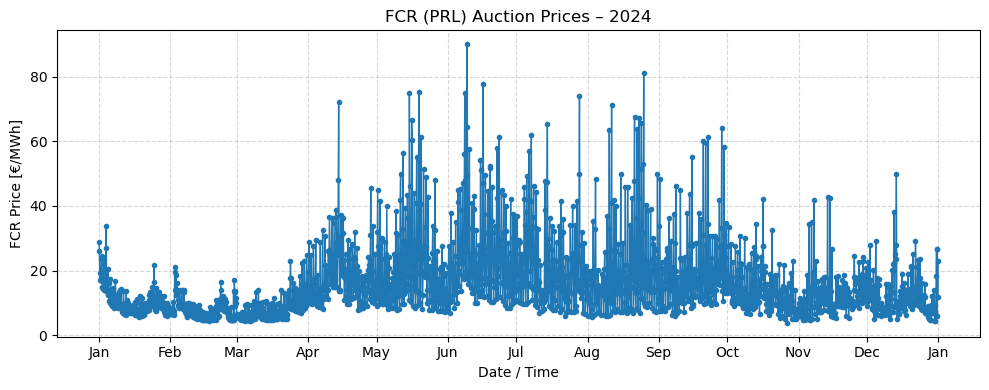

In [7]:
plot_fcr_prices(merged_FCR, year=2024, week=3) #Plot the FCR prices for a given week
plot_fcr_prices(merged_FCR, year=2024) #Plot the FCR prices for the whole year

In [8]:
# =========================
# Load AFRR prices
# =========================
afrr_folder = "data/Swissgrid_PRL_SRL_TRL"
years_to_load_AFRR = [2024]

AFRR_capacity_data = load_afrr_capacity_prices(afrr_folder, years_to_load_AFRR)

#Capcity prices based on weekly auction data. Energy activation prices assumed constant and defined in the parameter section above

#real auction is weekly, we model daily. Therefore we put the same price for each day per week from the historic data
AFRR_Pos_Cap_price = AFRR_capacity_data[2024]["pos"] 
AFRR_Neg_Cap_price = AFRR_capacity_data[2024]["neg"]
AFRR_Pos_Cap_price["price"] = AFRR_Pos_Cap_price["price"] 
AFRR_Neg_Cap_price["price"] = AFRR_Neg_Cap_price["price"] 



AFRR_Pos_Cap_price.head()


,timestamp,price
0,2024-01-01,7.159231
1,2024-01-02,7.159231
2,2024-01-03,7.159231
3,2024-01-04,7.159231
4,2024-01-05,7.159231


In [9]:
AFRR_Neg_Cap_price.head()

,timestamp,price
0,2024-01-01,19.057273
1,2024-01-02,19.057273
2,2024-01-03,19.057273
3,2024-01-04,19.057273
4,2024-01-05,19.057273


## Optimal dispatch solver Function for 72h price forecast

In [10]:
# =======================================
# Joint DA + FCR + aFRR solver for one window
# =======================================
def solve_da_fcr_afrr(
    da_block,
    fcr_prices_block,
    initial_soc,
    AFRR_Pos_Cap_price,
    AFRR_Neg_Cap_price,
    *,
    granularity_DA=1,
    granularity_FCR=4,
    granularity_AFRR =24,
    battery_capacity=40.0,
    soc_min=1.0,
    charge_rate_bounds=(0.0, 10.0),
    discharge_rate_bounds=(0, 10.0),
    efficiency=0.99,
    self_discharge_rate=3e-5,
    minimum_bid_FCR=1.0,
    wcs_factor_FCR=(0.36, 0.27, 0.18, 0.90),
    time_limit_seconds=300,
    gurobi_output=False,
    terminal_soc_target=None,
    activation_counter=activation_counter,
    year=2024,
):
    """
    Combined Day-Ahead + FCR optimization for one 72h horizon,
    using the simple FCR indexing style (4h blocks).
    """

    # === 1. Prepare DA prices and time grid
    da_block = da_block.sort_values("timestamp").reset_index(drop=True)
    clearing_price_DA = da_block["price_eur_mwh"].to_numpy(dtype=float)
    n_hours = len(clearing_price_DA)

    DA_horizon = range(int(n_hours / granularity_DA)) #number of 1h blocks
    FCR_horizon = range(int(n_hours / granularity_FCR))  # number of 4h blocks
    AFRR_horizon = range(int(n_hours / granularity_AFRR)) # number of 24h blocks 
    #print(len(DA_horizon), len(FCR_horizon), len(AFRR_horizon))

    clearing_price_FCR = fcr_prices_block["Preis"].to_numpy(dtype=float)
    assert len(clearing_price_FCR) == len(FCR_horizon), (
        f"FCR price length {len(clearing_price_FCR)} "
        f"≠ number of 4h blocks {len(FCR_horizon)}"
    )

    # === 2. Create optimization model
    MMO = gp.Model("DA_FCR_receding_horizon")
    MMO.Params.OutputFlag = 1 if gurobi_output else 0
    MMO.Params.TimeLimit = time_limit_seconds

    charge_lb, charge_ub = charge_rate_bounds
    discharge_lb, discharge_ub = discharge_rate_bounds

    #Decision variables
    Charge = MMO.addVars(n_hours, vtype=GRB.CONTINUOUS, lb=charge_lb, ub=charge_ub, name="Charge")
    Discharge = MMO.addVars(n_hours, vtype=GRB.CONTINUOUS, lb=discharge_lb, ub=discharge_ub, name="Discharge")
    Charging_Indicator = MMO.addVars(n_hours, vtype=GRB.BINARY, name="Charging_Indicator")
    SOC = MMO.addVars(n_hours + 1, vtype=GRB.CONTINUOUS, lb=soc_min, ub=battery_capacity, name="SOC")

    FCR_Participation = MMO.addVars(FCR_horizon, vtype=GRB.BINARY, name="FCR_Participation")
    FCR_Volume = MMO.addVars(FCR_horizon, vtype=GRB.CONTINUOUS, lb=0.0, ub=charge_ub, name="FCR_Volume")

    AFRR_Participation_Pos = MMO.addVars(AFRR_horizon, vtype=GRB.BINARY, name="AFRR_Participation_Pos")
    AFRR_Volume_Pos = MMO.addVars(AFRR_horizon, vtype=GRB.INTEGER, lb=0.0, ub=discharge_ub, name="AFRR_Volume_Pos")

    AFRR_Participation_Neg = MMO.addVars(AFRR_horizon, vtype=GRB.BINARY, name="AFRR_Participation_Neg")
    AFRR_Volume_Neg = MMO.addVars(AFRR_horizon, vtype=GRB.INTEGER, lb=0.0, ub=charge_ub, name="AFRR_Volume_Neg")

    # === 3. Battery SOC balance
    MMO.addConstr(SOC[0] == initial_soc)
    for h in AFRR_horizon:
        for i in range(granularity_AFRR):
            t = granularity_AFRR * h  + i
            MMO.addConstr(SOC[t + 1] == (1 - self_discharge_rate) * SOC[t] 
                          + granularity_DA * (efficiency * Charge[t] - (1 / efficiency) * Discharge[t]) 
                          + granularity_DA * utilization_factor_AFRR * ((efficiency * AFRR_Volume_Neg[h] - (1 / efficiency) * AFRR_Volume_Pos[h]))
            )
    #NB: The FCR energy content is modelled via headroom constraints below, not in the SOC balance directly
    #NB 2: the aFRR are scaled by an empirical utilization factor to account for the fact that not all bid volume is activated, this means that if we bid 1 MW of aFRR capacity, only 0.05 MW on average will be activated, so the impact on SOC is reduced accordingly.

    if terminal_soc_target is not None: # enforce terminal SOC for last time step!
        MMO.addConstr(SOC[n_hours] == terminal_soc_target)

    # === 4. Prevent simultaneous charge & discharge
    for t in range(n_hours):
        MMO.addGenConstrIndicator(Charging_Indicator[t], True, Discharge[t] == 0)
        MMO.addGenConstrIndicator(Charging_Indicator[t], False, Charge[t] == 0)

    # === 5. FCR constraints 
    for t in FCR_horizon:
        # Random number for activation
        rng = np.random.default_rng(seed=activation_counter)
        random_value = rng.random()
        activation_counter += 1

        # Minimum bid if participating
        if random_value <= acceptance_rate[year]: 
            MMO.addConstr(FCR_Participation[t] * minimum_bid_FCR <= FCR_Volume[t])
            MMO.addConstr(FCR_Volume[t] <= charge_ub * FCR_Participation[t])

        else:  # no participation
            MMO.addConstr(FCR_Volume[t] == 0)

    # === 6. AFRR constraints
    for t in AFRR_horizon:
        # Minimum bid if participating for positive (upward) regulation
        MMO.addConstr(AFRR_Participation_Pos[t] * minimum_bid_AFRR <= AFRR_Volume_Pos[t])
        MMO.addConstr(AFRR_Volume_Pos[t] <= charge_ub * AFRR_Participation_Pos[t])

        # Minimum bid if participating for negative (downward) regulation
        MMO.addConstr(AFRR_Participation_Neg[t] * minimum_bid_AFRR <= AFRR_Volume_Neg[t])
        MMO.addConstr(AFRR_Volume_Neg[t] <= charge_ub * AFRR_Participation_Neg[t])

    # # # == 7. Model SOC headroom and Power headroom, taking into account the different time granularities
    # for t in AFRR_horizon: #AFRR_horizon = range(3) in our 72h loop
    #     for i in range(granularity_AFRR//granularity_FCR): #24//4=6
    #         h = t * granularity_AFRR//granularity_FCR + i #map to FCR block index
    #         for j in range(granularity_FCR): #j=0,1,2,3
    #             k = h * granularity_FCR +j #map to hour index
                
    #             # SOC headroom
    #             MMO.addConstr(SOC[k] >= soc_min + FCR_Volume[h] * wcs_factor_FCR[j] + AFRR_Volume_Pos[t] * wcs_factor_AFRR)
    #             MMO.addConstr(SOC[k] <= battery_capacity - FCR_Volume[h] * wcs_factor_FCR[j] - AFRR_Volume_Neg[t] * wcs_factor_AFRR)
    #             #wcs_factor_aFRR = 1.8 MWh/MW represents how much we virtually reduce our remaining battery capacity to allow low risk participation in other markets.

    #             # Power headroom
    #             MMO.addConstr(Discharge[k] + FCR_Volume[h] + AFRR_Volume_Pos[t] <= discharge_ub)
    #             MMO.addConstr(Charge[k] + FCR_Volume[h] + AFRR_Volume_Neg[t] <= charge_ub)

    # === 7.  SOC and Power headroom constraints (clean version)
    for k in range(n_hours):

        # FCR mapping
        f = k // granularity_FCR          # FCR block index (0..17)
        j = k % granularity_FCR           # hour inside the block (0..3)

        # AFRR mapping
        a = k // granularity_AFRR         # AFRR block index (0..2)

        # SOC headroom
        MMO.addConstr(SOC[k] >= soc_min + FCR_Volume[f] * wcs_factor_FCR[j] + AFRR_Volume_Pos[a] * wcs_factor_AFRR)
        MMO.addConstr(SOC[k] <= battery_capacity - FCR_Volume[f] * wcs_factor_FCR[j] - AFRR_Volume_Neg[a] * wcs_factor_AFRR)

        # Power limits
        MMO.addConstr(Discharge[k] + FCR_Volume[f] + AFRR_Volume_Pos[a] <= discharge_ub)
        MMO.addConstr(Charge[k] + FCR_Volume[f] + AFRR_Volume_Neg[a] <= charge_ub)


    # === 8. Limit daily cycling over 3 days ===
    max_daily_cycles = 1
    avg_agg_FCR_discharge = 0.136  # MWh/MW of FCR Volume capacity per 4 hours
    n_days = n_hours // 24  # number of complete 24h days in the horizon
    for d in range(n_days):
        MMO.addConstr(
            quicksum(Discharge[24//granularity_DA * d + t] for t in range(24//granularity_DA))
            + quicksum(avg_agg_FCR_discharge * FCR_Volume[24//granularity_FCR * d + t] for t in range(24//granularity_FCR))
            + AFRR_Volume_Pos[d] * utilization_factor_AFRR * granularity_AFRR
            <= max_daily_cycles * battery_capacity
        ) 

    # === 9. Objective (DA + FCR + AFRR revenue)
    DA_term = quicksum(clearing_price_DA[t] * (Discharge[t] - Charge[t]) * granularity_DA for t in range(n_hours))
    FCR_term = quicksum(FCR_Volume[t] * clearing_price_FCR[t] * granularity_FCR for t in FCR_horizon)
    
    AFRR_Pos_Cap_term =  quicksum(AFRR_Volume_Pos[t] * AFRR_Pos_Cap_price[t] * granularity_AFRR for t in AFRR_horizon)
    AFRR_Neg_Cap_term =  quicksum(AFRR_Volume_Neg[t] * AFRR_Neg_Cap_price[t]* granularity_AFRR for t in AFRR_horizon)

    AFRR_Pos_Act_term =  quicksum(utilization_factor_AFRR * AFRR_Volume_Pos[t] * AFRR_Pos_Act_price * granularity_AFRR for t in AFRR_horizon)
    AFRR_Neg_Act_term =  quicksum(utilization_factor_AFRR * AFRR_Volume_Neg[t] * AFRR_Neg_Act_price * granularity_AFRR  for t in AFRR_horizon)


    MMO.setObjective(DA_term + FCR_term + AFRR_Pos_Cap_term + AFRR_Neg_Cap_term + AFRR_Pos_Act_term + AFRR_Neg_Act_term, GRB.MAXIMIZE)
    MMO.optimize()

    # === 10. Extract solution
    schedule = {
        "charge": np.array([Charge[t].X for t in range(n_hours)]),
        "discharge": np.array([Discharge[t].X for t in range(n_hours)]),
        "soc": np.array([SOC[t].X for t in range(n_hours + 1)]),
        "fcr_volume": np.array([FCR_Volume[t].X for t in FCR_horizon]),
        "afrr_volume_pos": np.array([AFRR_Volume_Pos[t].X for t in AFRR_horizon]),
        "afrr_volume_neg": np.array([AFRR_Volume_Neg[t].X for t in AFRR_horizon]),
        "afrr_participation_pos": np.array([AFRR_Participation_Pos[t].X for t in AFRR_horizon]),
        "afrr_participation_neg": np.array([AFRR_Participation_Neg[t].X for t in AFRR_horizon]),
    }

    return {
        "objective_value": MMO.ObjVal,
        "schedule": schedule,
        "terminal_soc": schedule["soc"][-1],
    }

## Receding Horizon Loop for one year


In [11]:
# =====================================================
# RECEDING HORIZON LOOP (72h look-ahead, 24h apply)
# =====================================================

look_ahead_hours = 72 # 3 days, each optimization looks at 72 hours of price 
apply_hours = 24
state_soc = initial_SOC

timestamps = DA_prices_merged["timestamp"]
start_time = timestamps.min()
end_time = timestamps.max()

hourly_rows = []
daily_rows = []

current_time = start_time  # initialize the moving window start time

while current_time + pd.Timedelta(hours=apply_hours) <= end_time: ##loop 24h at a time until we reach the end of the data

    # Select DA window (72h)
    horizon_end = current_time + pd.Timedelta(hours=look_ahead_hours)
    da_block = DA_prices_merged[
        (DA_prices_merged["timestamp"] >= current_time)
        & (DA_prices_merged["timestamp"] < horizon_end)
    ].copy() #select 72h block for DA prices, will return 72 1h blocks prices

    if len(da_block) == 0:
        print(f"Skipping {current_time.date()} — no DA data available.")
        current_time += pd.Timedelta(hours=apply_hours)
        continue

    # Select corresponding FCR window (same 72h)
    fcr_prices_block = merged_FCR[
        (merged_FCR["timestamp"] >= current_time)
        & (merged_FCR["timestamp"] < horizon_end)
    ].copy() #select 72h block for FCR prices, will return 18 4h blocks prices

    # Select AFRR capacity prices for the current horizon
    afrr_pos_prices_block = AFRR_Pos_Cap_price[
        (AFRR_Pos_Cap_price["timestamp"] >= current_time.normalize())
        & (AFRR_Pos_Cap_price["timestamp"] < (current_time + pd.Timedelta(hours=look_ahead_hours)).normalize())
    ]["price"].to_numpy()
    # normalize() sets the time to 00:00:00, we get arrays of length = number of days in the horizon (3 for 72h horizon)
    afrr_neg_prices_block = AFRR_Neg_Cap_price[
        (AFRR_Neg_Cap_price["timestamp"] >= current_time.normalize())
        & (AFRR_Neg_Cap_price["timestamp"] < (current_time + pd.Timedelta(hours=look_ahead_hours)).normalize())
    ]["price"].to_numpy()
    
    target_len = look_ahead_hours // granularity_AFRR  #number of 24h blocks in the horizon (3 for 72h horizon)
    # Pad POS, for cases where we are at the end of the year and don't have enough days
    if len(afrr_pos_prices_block) < target_len:
        pad_val = afrr_pos_prices_block[-1]   # last known value
        afrr_pos_prices_block = np.concatenate(
            [afrr_pos_prices_block, np.full(target_len - len(afrr_pos_prices_block), pad_val)]
        )

    # Pad NEG, for cases where we are at the end of the year and don't have enough days
    if len(afrr_neg_prices_block) < target_len:
        pad_val = afrr_neg_prices_block[-1]
        afrr_neg_prices_block = np.concatenate(
            [afrr_neg_prices_block, np.full(target_len - len(afrr_neg_prices_block), pad_val)]
        )

    # Terminal SOC for last horizon
    target_soc = initial_SOC if horizon_end >= end_time else None

    # Solve DA+FCR optimization for the next 72h
    result = solve_da_fcr_afrr(
        da_block,
        fcr_prices_block,
        state_soc,
        AFRR_Pos_Cap_price = afrr_pos_prices_block,
        AFRR_Neg_Cap_price = afrr_neg_prices_block,
        granularity_DA=granularity_DA,
        granularity_FCR=granularity_FCR,
        battery_capacity=battery_capacity,
        soc_min=SOC_min,
        charge_rate_bounds=(charge_rate_min, charge_rate_max),
        discharge_rate_bounds=(discharge_rate_min, discharge_rate_max),
        efficiency=efficiency,
        self_discharge_rate=self_discharge_rate,
        minimum_bid_FCR=minimum_bid_FCR,
        wcs_factor_FCR=wcs_factor_FCR,
        time_limit_seconds=300,
        gurobi_output=False,
        terminal_soc_target=target_soc,
        activation_counter=activation_counter,
        year=current_time.year,
    )
    
    #Update activation counter
    activation_counter += 6 #6 FCR blocks per 24h apply period

    # Extract optimal schedule for the next 72h
    schedule = result["schedule"] #dictionary with keys: "charge", "discharge", "soc", "fcr_volume"
    soc_profile = schedule["soc"]
    charge = schedule["charge"]
    discharge = schedule["discharge"]
    fcr_volume = schedule["fcr_volume"]
    afrr_volume_pos = schedule["afrr_volume_pos"]
    afrr_volume_neg = schedule["afrr_volume_neg"]
    afrr_part_pos = schedule["afrr_participation_pos"]
    afrr_part_neg = schedule["afrr_participation_neg"]

    n_apply = int(apply_hours / granularity_DA) #number of hours to apply (24h)
    block_apply = da_block.iloc[:n_apply].copy()

    # --- record hourly dispatch, but only for the first 24h ---
    for t in range(n_apply):
        ts = block_apply["timestamp"].iloc[t]
        hourly_rows.append({
            "timestamp": ts,
            "charge_mw": charge[t],
            "discharge_mw": discharge[t],
            "soc_mwh": soc_profile[t + 1],
            "fcr_reserve_mw": fcr_volume[t // granularity_FCR],
            "price_eur_mwh": block_apply["price_eur_mwh"].iloc[t],
            "afrr_volume_pos_mw": afrr_volume_pos[t // granularity_AFRR],
            "afrr_volume_neg_mw": afrr_volume_neg[t // granularity_AFRR],
            "afrr_participation_pos": afrr_part_pos[t // granularity_AFRR],
            "afrr_participation_neg": afrr_part_neg[t // granularity_AFRR],
        })

    # --- compute realized profits ---
    #DA revenue 
    net_export = discharge[:n_apply] - charge[:n_apply]
    da_profit = float(np.dot(block_apply["price_eur_mwh"].to_numpy(), net_export) * granularity_DA)

    # FCR revenue: 4h blocks starting within the first 24h
    n_fcr_apply = int(apply_hours / granularity_FCR) #number of 4h blocks to apply (6 blocks)
    fcr_prices_apply = fcr_prices_block.head(n_fcr_apply)#only the first n_fcr_apply=6 rows
    fcr_revenue = float(np.dot(schedule["fcr_volume"][:n_fcr_apply],fcr_prices_apply["Preis"].to_numpy())*granularity_FCR)

    # === AFRR capacity revenue (24h block)
    n_afrr_apply = int(apply_hours / granularity_AFRR)  # = 1 block for 24h 
    afrr_vol_pos_apply = schedule["afrr_volume_pos"][:n_afrr_apply]
    afrr_vol_neg_apply = schedule["afrr_volume_neg"][:n_afrr_apply]

        # Capacity revenue (CHF/MW/day)
    afrr_cap_pos_revenue = float(np.dot(afrr_vol_pos_apply, afrr_pos_prices_block[:n_afrr_apply]) * granularity_AFRR)

    afrr_cap_neg_revenue = float(np.dot(afrr_vol_neg_apply, afrr_neg_prices_block[:n_afrr_apply]) * granularity_AFRR)

        # === AFRR activation revenue (constant €/MWh)
    # Activation energy = utilization_factor * capacity * 24h
    afrr_act_pos_revenue = float(np.sum(afrr_vol_pos_apply)* granularity_AFRR
        * utilization_factor_AFRR
        * AFRR_Pos_Act_price
    )

    afrr_act_neg_revenue = float(np.sum(afrr_vol_neg_apply)* granularity_AFRR
        * utilization_factor_AFRR
        * AFRR_Neg_Act_price
    )

    afrr_total_revenue = (afrr_cap_pos_revenue + afrr_cap_neg_revenue +
                        afrr_act_pos_revenue + afrr_act_neg_revenue)

    # === Combined revenue for this 24h slice
    total_profit = da_profit + fcr_revenue + afrr_total_revenue

    # Save results
    daily_rows.append({
        "run_time": current_time,
        "profit_model": result["objective_value"],
        "profit_realized": total_profit,
        "da_profit": da_profit,
        "fcr_revenue": fcr_revenue,
        "afrr_cap_pos": afrr_cap_pos_revenue,
        "afrr_cap_neg": afrr_cap_neg_revenue,
        "afrr_act_pos": afrr_act_pos_revenue,
        "afrr_act_neg": afrr_act_neg_revenue,
        "afrr_total": afrr_total_revenue,
        "terminal_soc": soc_profile[n_apply],
    })

    # 6 Update SOC and move horizon forward
    state_soc = soc_profile[n_apply]
    current_time += pd.Timedelta(hours=apply_hours)

# =====================================================
# RESULTS
# =====================================================
profit_df = pd.DataFrame(daily_rows)
dispatch_df = pd.DataFrame(hourly_rows)
annual_profit = profit_df["profit_realized"].sum()

print(f"Simulated {len(profit_df)} receding-horizon steps.")
print(f"Total DA + FCR + aFRR profit: {annual_profit:,.2f} €")


Set parameter Username
Set parameter LicenseID to value 2640286
Academic license - for non-commercial use only - expires 2026-03-20
Simulated 365 receding-horizon steps.
Total DA + FCR + aFRR profit: 2,448,225.47 €


## Extracting Results

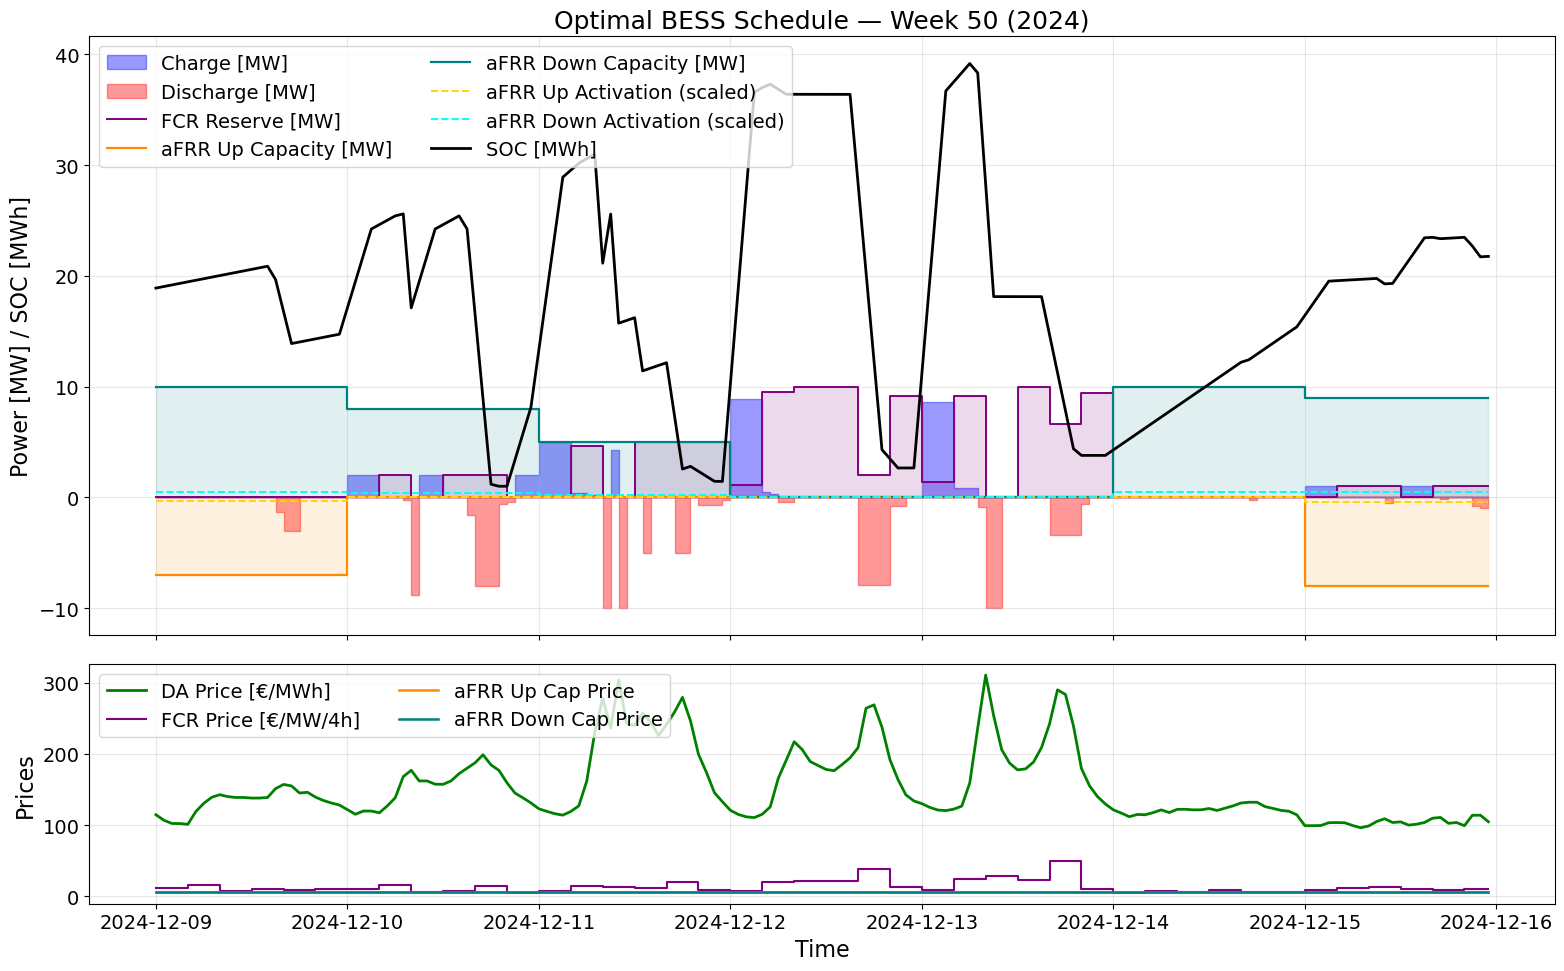

In [12]:
# =====================================================
# WEEKLY VISUALIZATION — DA + FCR + aFRR
# =====================================================

week_number = 50  # choose week to visualize
hours_per_week = 24 * 7
start_idx = (week_number - 1) * hours_per_week
end_idx = start_idx + hours_per_week

# --- Extract hourly data for that week ---
dfw = dispatch_df.iloc[start_idx:end_idx]

time_week = dfw["timestamp"]
Charge_week = dfw["charge_mw"].to_numpy()
Discharge_week = dfw["discharge_mw"].to_numpy()
SOC_week = dfw["soc_mwh"].to_numpy()
Price_week = dfw["price_eur_mwh"].to_numpy()
FCR_reserve_week = dfw["fcr_reserve_mw"].to_numpy()

AFRR_pos_week = dfw["afrr_volume_pos_mw"].to_numpy()
AFRR_neg_week = dfw["afrr_volume_neg_mw"].to_numpy()
AFRR_pos_part_week = dfw["afrr_participation_pos"].to_numpy()
AFRR_neg_part_week = dfw["afrr_participation_neg"].to_numpy()

# Activation (scaled)
AFRR_pos_act_week = AFRR_pos_week * utilization_factor_AFRR
AFRR_neg_act_week = AFRR_neg_week * utilization_factor_AFRR

# =====================================================
# BUILD AFRR PRICE TIMESERIES (24h → 1h)
# =====================================================
# aFRR capacity prices are daily. Repeat each value for 24 hours.
afrr_pos_price_daily = AFRR_Pos_Cap_price["price"].to_numpy()
afrr_neg_price_daily = AFRR_Neg_Cap_price["price"].to_numpy()

afrr_pos_price_hourly = np.repeat(afrr_pos_price_daily, 24)
afrr_neg_price_hourly = np.repeat(afrr_neg_price_daily, 24)

# Clip to simulation
afrr_pos_price_hourly = afrr_pos_price_hourly[: len(dispatch_df)]
afrr_neg_price_hourly = afrr_neg_price_hourly[: len(dispatch_df)]

# Select week
AFRR_pos_price_week = afrr_pos_price_hourly[start_idx:end_idx]
AFRR_neg_price_week = afrr_neg_price_hourly[start_idx:end_idx]

# =====================================================
# EXPAND FCR PRICES (4h → 1h)
# =====================================================
FCR_price_hourly = np.repeat(merged_FCR["Preis"].to_numpy(), granularity_FCR)
FCR_price_hourly = FCR_price_hourly[: len(dispatch_df)]
FCR_price_week = FCR_price_hourly[start_idx:end_idx]

# =====================================================
# PLOTTING
# =====================================================
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

fig, axs = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                        gridspec_kw={"height_ratios": [2.5, 1]})

# =====================================================
# --- TOP PANEL: DISPATCH + RESERVES + ACTIVATION ---
# =====================================================
axs[0].fill_between(time_week, 0, Charge_week, step="post",
                    alpha=0.4, color="blue", label="Charge [MW]")
axs[0].fill_between(time_week, 0, -Discharge_week, step="post",
                    alpha=0.4, color="red", label="Discharge [MW]")

# FCR reserve
axs[0].step(time_week, FCR_reserve_week, where="post",
            color="purple", linewidth=1.4, label="FCR Reserve [MW]")
axs[0].fill_between(time_week, 0, FCR_reserve_week,
                    step="post", alpha=0.15, color="purple")

# aFRR capacity (positive / negative)
axs[0].step(time_week, -AFRR_pos_week, where="post",
            color="darkorange", linewidth=1.6, label="aFRR Up Capacity [MW]")
axs[0].fill_between(time_week, 0, -AFRR_pos_week, step="post",
                    alpha=0.12, color="darkorange")

axs[0].step(time_week, AFRR_neg_week, where="post",
            color="teal", linewidth=1.6, label="aFRR Down Capacity [MW]")
axs[0].fill_between(time_week, 0, AFRR_neg_week, step="post",
                    alpha=0.12, color="teal")

# aFRR activation (scaled)
axs[0].step(time_week, -AFRR_pos_act_week, where="post",
            color="gold", linewidth=1.4, linestyle="--",
            label="aFRR Up Activation (scaled)")
axs[0].step(time_week, AFRR_neg_act_week, where="post",
            color="cyan", linewidth=1.4, linestyle="--",
            label="aFRR Down Activation (scaled)")

# SOC curve
axs[0].plot(time_week, SOC_week, color="black", linewidth=2.0,
            label="SOC [MWh]")

axs[0].set_ylabel("Power [MW] / SOC [MWh]")
axs[0].set_title(f"Optimal BESS Schedule — Week {week_number} ({time_week.dt.year.iloc[0]})")
axs[0].grid(True, alpha=0.3)
axs[0].legend(loc="upper left", ncol=2)

# =====================================================
# --- BOTTOM PANEL: MARKET PRICES ---
# =====================================================
axs[1].plot(time_week, Price_week, color="green", linewidth=2.0,
            label="DA Price [€/MWh]")
axs[1].step(time_week, FCR_price_week, where="post",
            color="purple", linewidth=1.5, label="FCR Price [€/MW/4h]")

# AFRR capacity prices (CHF/MW/day → plotted as is)
axs[1].step(time_week, AFRR_pos_price_week, where="post",
            color="darkorange", linewidth=1.8, label="aFRR Up Cap Price")
axs[1].step(time_week, AFRR_neg_price_week, where="post",
            color="teal", linewidth=1.8, label="aFRR Down Cap Price")

axs[1].grid(True, alpha=0.3)
axs[1].set_ylabel("Prices")
axs[1].set_xlabel("Time")

axs[1].legend(loc="upper left", ncol=2)

plt.tight_layout()
plt.show()


## Computing yearly optimal dispatch with receding horizon over multiple years.

In [13]:
def run_receding_horizon_single_year(year, DA_all, FCR_all, AFRR_cap_all):
    """
    Runs the 72h-lookahead / 24h-apply loop for one year with DA + FCR + aFRR.

    Uses globals from the notebook: initial_SOC, granularity_DA, granularity_FCR, granularity_AFRR,
    SOC_min, charge_rate_min/max, discharge_rate_min/max, efficiency, self_discharge_rate,
    minimum_bid_FCR, minimum_bid_AFRR, wcs_factor_FCR, wcs_factor_AFRR, utilization_factor_AFRR,
    solve_da_fcr_afrr, AFRR_Pos_Act_price, AFRR_Neg_Act_price.
    """
    global activation_counter

    DA_prices_merged = DA_all[DA_all["timestamp"].dt.year == year].copy()
    merged_FCR = FCR_all[FCR_all["timestamp"].dt.year == year].copy()

    if year not in AFRR_cap_all:
        print(f"[{year}] No aFRR capacity data available.")
        return {
            "year": year, "da_profit": 0.0, "fcr_revenue": 0.0, "afrr_total": 0.0,
            "total_profit": 0.0, "profit_df": pd.DataFrame(), "dispatch_df": pd.DataFrame(),
        }

    AFRR_Pos_Cap_price = AFRR_cap_all[year]["pos"].copy()
    AFRR_Neg_Cap_price = AFRR_cap_all[year]["neg"].copy()

    if DA_prices_merged.empty:
        print(f"[{year}] No DA data available.")
        return {
            "year": year, "da_profit": 0.0, "fcr_revenue": 0.0, "afrr_total": 0.0,
            "total_profit": 0.0, "profit_df": pd.DataFrame(), "dispatch_df": pd.DataFrame(),
        }

    look_ahead_hours = 72
    apply_hours = 24
    state_soc = initial_SOC

    timestamps = DA_prices_merged["timestamp"]
    start_time = timestamps.min()
    end_time = timestamps.max()

    hourly_rows = []
    daily_rows = []

    current_time = start_time
    while current_time + pd.Timedelta(hours=apply_hours) <= end_time:
        horizon_end = current_time + pd.Timedelta(hours=look_ahead_hours)

        da_block = DA_prices_merged[
            (DA_prices_merged["timestamp"] >= current_time)
            & (DA_prices_merged["timestamp"] < horizon_end)
        ].copy()
        if len(da_block) == 0:
            print(f"Skipping {current_time.date()} — no DA data available.")
            current_time += pd.Timedelta(hours=apply_hours)
            continue

        fcr_prices_block = merged_FCR[
            (merged_FCR["timestamp"] >= current_time)
            & (merged_FCR["timestamp"] < horizon_end)
        ].copy()

        # aFRR capacity prices for this horizon (daily)
        afrr_pos_prices_block = AFRR_Pos_Cap_price[
            (AFRR_Pos_Cap_price["timestamp"] >= current_time.normalize())
            & (AFRR_Pos_Cap_price["timestamp"] < horizon_end.normalize())
        ]["price"].to_numpy()
        afrr_neg_prices_block = AFRR_Neg_Cap_price[
            (AFRR_Neg_Cap_price["timestamp"] >= current_time.normalize())
            & (AFRR_Neg_Cap_price["timestamp"] < horizon_end.normalize())
        ]["price"].to_numpy()

        target_len = look_ahead_hours // granularity_AFRR
        if len(afrr_pos_prices_block) < target_len:
            pad_val = afrr_pos_prices_block[-1]
            afrr_pos_prices_block = np.concatenate(
                [afrr_pos_prices_block, np.full(target_len - len(afrr_pos_prices_block), pad_val)]
            )
        if len(afrr_neg_prices_block) < target_len:
            pad_val = afrr_neg_prices_block[-1]
            afrr_neg_prices_block = np.concatenate(
                [afrr_neg_prices_block, np.full(target_len - len(afrr_neg_prices_block), pad_val)]
            )

        target_soc = initial_SOC if horizon_end >= end_time else None

        result = solve_da_fcr_afrr(
            da_block,
            fcr_prices_block,
            state_soc,
            AFRR_Pos_Cap_price=afrr_pos_prices_block,
            AFRR_Neg_Cap_price=afrr_neg_prices_block,
            granularity_DA=granularity_DA,
            granularity_FCR=granularity_FCR,
            granularity_AFRR=granularity_AFRR,
            battery_capacity=battery_capacity,
            soc_min=SOC_min,
            charge_rate_bounds=(charge_rate_min, charge_rate_max),
            discharge_rate_bounds=(discharge_rate_min, discharge_rate_max),
            efficiency=efficiency,
            self_discharge_rate=self_discharge_rate,
            minimum_bid_FCR=minimum_bid_FCR,
            wcs_factor_FCR=wcs_factor_FCR,
            time_limit_seconds=300,
            gurobi_output=False,
            terminal_soc_target=target_soc,
            activation_counter=activation_counter,
            year=current_time.year,
        )

        # Update activation counter after 72h horizon draw
        activation_counter += 6  # 6 FCR blocks per 24h apply period

        schedule = result["schedule"]
        soc_profile = schedule["soc"]
        charge = schedule["charge"]
        discharge = schedule["discharge"]
        fcr_volume = schedule["fcr_volume"]
        afrr_volume_pos = schedule["afrr_volume_pos"]
        afrr_volume_neg = schedule["afrr_volume_neg"]
        afrr_part_pos = schedule["afrr_participation_pos"]
        afrr_part_neg = schedule["afrr_participation_neg"]

        n_apply = int(apply_hours / granularity_DA)
        block_apply = da_block.iloc[:n_apply].copy()

        for t in range(n_apply):
            ts = block_apply["timestamp"].iloc[t]
            hourly_rows.append({
                "timestamp": ts,
                "charge_mw": charge[t],
                "discharge_mw": discharge[t],
                "soc_mwh": soc_profile[t + 1],
                "fcr_reserve_mw": fcr_volume[t // granularity_FCR],
                "price_eur_mwh": block_apply["price_eur_mwh"].iloc[t],
                "afrr_volume_pos_mw": afrr_volume_pos[t // granularity_AFRR],
                "afrr_volume_neg_mw": afrr_volume_neg[t // granularity_AFRR],
                "afrr_participation_pos": afrr_part_pos[t // granularity_AFRR],
                "afrr_participation_neg": afrr_part_neg[t // granularity_AFRR],
            })

        # Realized profits (first 24h only)
        net_export = discharge[:n_apply] - charge[:n_apply]
        da_profit = float(np.dot(block_apply["price_eur_mwh"].to_numpy(), net_export) * granularity_DA)

        n_fcr_apply = int(apply_hours / granularity_FCR)
        fcr_prices_apply = fcr_prices_block.head(n_fcr_apply)
        fcr_revenue = 0.0
        if not fcr_prices_apply.empty:
            fcr_revenue = float(np.dot(fcr_volume[:n_fcr_apply], fcr_prices_apply["Preis"].to_numpy()) * granularity_FCR)

        n_afrr_apply = int(apply_hours / granularity_AFRR)  # = 1
        afrr_vol_pos_apply = afrr_volume_pos[:n_afrr_apply]
        afrr_vol_neg_apply = afrr_volume_neg[:n_afrr_apply]

        afrr_cap_pos_revenue = float(np.dot(afrr_vol_pos_apply, afrr_pos_prices_block[:n_afrr_apply]) * granularity_AFRR)
        afrr_cap_neg_revenue = float(np.dot(afrr_vol_neg_apply, afrr_neg_prices_block[:n_afrr_apply]) * granularity_AFRR)

        afrr_act_pos_revenue = float(np.sum(afrr_vol_pos_apply) * granularity_AFRR * utilization_factor_AFRR * AFRR_Pos_Act_price)
        afrr_act_neg_revenue = float(np.sum(afrr_vol_neg_apply) * granularity_AFRR * utilization_factor_AFRR * AFRR_Neg_Act_price)

        afrr_total_revenue = afrr_cap_pos_revenue + afrr_cap_neg_revenue + afrr_act_pos_revenue + afrr_act_neg_revenue

        total_profit = da_profit + fcr_revenue + afrr_total_revenue

        daily_rows.append({
            "run_time": current_time,
            "profit_model": result["objective_value"],
            "profit_realized": total_profit,
            "da_profit": da_profit,
            "fcr_revenue": fcr_revenue,
            "afrr_cap_pos": afrr_cap_pos_revenue,
            "afrr_cap_neg": afrr_cap_neg_revenue,
            "afrr_act_pos": afrr_act_pos_revenue,
            "afrr_act_neg": afrr_act_neg_revenue,
            "afrr_total": afrr_total_revenue,
            "terminal_soc": soc_profile[n_apply],
        })

        state_soc = float(soc_profile[n_apply])
        current_time += pd.Timedelta(hours=apply_hours)

    profit_df = pd.DataFrame(daily_rows)
    dispatch_df = pd.DataFrame(hourly_rows)

    da_profit_total = float(profit_df["da_profit"].sum()) if not profit_df.empty else 0.0
    fcr_revenue_total = float(profit_df["fcr_revenue"].sum()) if not profit_df.empty else 0.0
    afrr_revenue_total = float(profit_df["afrr_total"].sum()) if not profit_df.empty else 0.0
    total_profit = float(profit_df["profit_realized"].sum()) if not profit_df.empty else 0.0

    print(f"[{year}] Simulated {len(profit_df)} receding-horizon steps.")
    print(f"[{year}] Total DA + FCR + aFRR profit: {total_profit:,.2f} €")

    return {
        "year": year,
        "da_profit": da_profit_total,
        "fcr_revenue": fcr_revenue_total,
        "afrr_total": afrr_revenue_total,
        "total_profit": total_profit,
        "profit_df": profit_df,
        "dispatch_df": dispatch_df,
    }


Loaded and merged 16 FCR files (35064 total rows).
[2029] Simulated 364 receding-horizon steps.
[2029] Total DA + FCR + aFRR profit: 2,195,394.24 €
[2030] Simulated 364 receding-horizon steps.
[2030] Total DA + FCR + aFRR profit: 2,187,814.36 €
[2031] Simulated 364 receding-horizon steps.
[2031] Total DA + FCR + aFRR profit: 2,178,960.01 €
[2032] Simulated 365 receding-horizon steps.
[2032] Total DA + FCR + aFRR profit: 2,180,653.32 €
[2033] Simulated 364 receding-horizon steps.
[2033] Total DA + FCR + aFRR profit: 2,171,447.39 €
[2034] Simulated 364 receding-horizon steps.
[2034] Total DA + FCR + aFRR profit: 2,165,296.90 €
[2035] Simulated 364 receding-horizon steps.
[2035] Total DA + FCR + aFRR profit: 2,158,866.80 €
[2036] Simulated 365 receding-horizon steps.
[2036] Total DA + FCR + aFRR profit: 2,159,896.05 €
[2037] Simulated 364 receding-horizon steps.
[2037] Total DA + FCR + aFRR profit: 2,151,634.05 €
[2038] Simulated 364 receding-horizon steps.
[2038] Total DA + FCR + aFRR pr

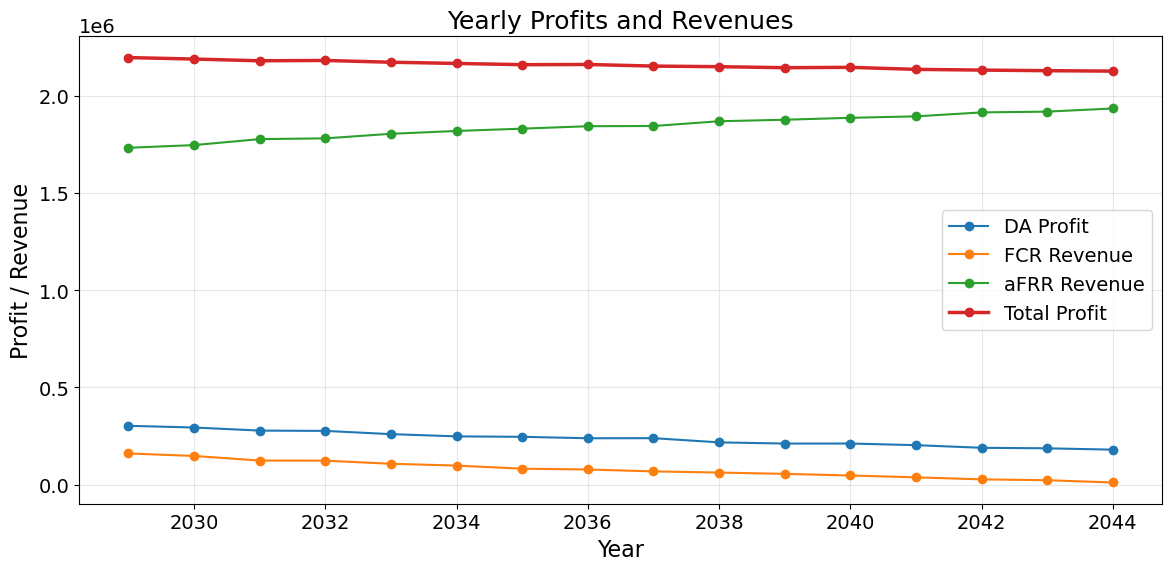

Results saved to Results\yearly_results.xlsx


In [14]:
# selecting multiple years to run the receding horizon simulation
years = list(range(2029, 2045))

# Load DA (shift +1h, tz-naive, sorted)
DA_all = load_da_market_data(da_folder, years)
DA_all["timestamp"] = pd.to_datetime(DA_all["timestamp"]) + pd.Timedelta(hours=1)
DA_all["timestamp"] = DA_all["timestamp"].dt.tz_localize(None)
DA_all = DA_all.sort_values("timestamp").reset_index(drop=True)

# Load FCR (expects PRL_filled_<year>.csv for each year)
merged_FCR_all = load_fcr_prices(fcr_folder, years)

# Load aFRR capacity (weekly → daily) and scale by 0.5 as before
AFRR_capacity_all = load_afrr_capacity_prices(afrr_folder, years)

all_results = []
for y in years:
    degraded_capacity = max(initial_capacity - degradation_per_year * (y - 2024), 0)

    r = run_receding_horizon_single_year(
        y,
        DA_all,
        merged_FCR_all,
        AFRR_capacity_all,
    )
    all_results.append({
        "Year": r["year"],
        "DA_Profit": r["da_profit"],
        "FCR_Revenue": r["fcr_revenue"],
        "AFRR_Revenue": r["afrr_total"],
        "Total_Profit": r["total_profit"],
    })

results_df = pd.DataFrame(all_results).sort_values("Year").reset_index(drop=True)
print(results_df)

# Plot yearly profits/revenues
plt.figure(figsize=(12, 6))
plt.plot(results_df["Year"], results_df["DA_Profit"], marker="o", label="DA Profit")
plt.plot(results_df["Year"], results_df["FCR_Revenue"], marker="o", label="FCR Revenue")
plt.plot(results_df["Year"], results_df["AFRR_Revenue"], marker="o", label="aFRR Revenue")
plt.plot(results_df["Year"], results_df["Total_Profit"], marker="o", linewidth=2.5, label="Total Profit")
plt.xlabel("Year")
plt.ylabel("Profit / Revenue")
plt.title("Yearly Profits and Revenues")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Export results to Excel
results_folder = os.path.join("Results")
os.makedirs(results_folder, exist_ok=True)
excel_path = os.path.join(results_folder, "yearly_results.xlsx")
results_df.to_excel(excel_path, index=False)
print(f"Results saved to {excel_path}")
